In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ToDo: change the path before submitting
df = pd.read_json(r"resources/emoset_challenge_1000_augmented.json")

# unpacking the annotations dictionary and merging back into the main data frame
annotations_df = df['annotations'].apply(pd.Series)
df = pd.concat([df, annotations_df], axis=1) # sticking the new column we got side by side in the original table


# asking questions in order to understand the dataset
display(df.info(show_counts=True))
#pd.set_option('display.max_columns', None)
display("Duplicate image names:", df['image_name'].duplicated().sum()) # checking image names looking for bias
display("Embedding type:", type(df.loc[0, 'embedding'])) # checking embeddings
display("Embedding length summary:", df['embedding'].apply(len).describe()) # Check embedding length consistency

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   image_name                 1000 non-null   object 
 1   annotations                1000 non-null   object 
 2   description                1000 non-null   object 
 3   embedding                  1000 non-null   object 
 4   viewer_feelings            1000 non-null   object 
 5   description_embedding      1000 non-null   object 
 6   viewer_feelings_embedding  1000 non-null   object 
 7   image_id                   1000 non-null   object 
 8   emotion                    1000 non-null   object 
 9   brightness                 999 non-null    float64
 10  colorfulness               976 non-null    float64
 11  facial_expression          112 non-null    object 
 12  object                     513 non-null    object 
 13  human_action               114 non-null    object

None

'Duplicate image names:'

np.int64(0)

'Embedding type:'

list

'Embedding length summary:'

count    1000.0
mean      512.0
std         0.0
min       512.0
25%       512.0
50%       512.0
75%       512.0
max       512.0
Name: embedding, dtype: float64

In [ ]:
# Handle Missing Data

## brightness and colorfulness have a low % missing, so drop rows with missing values
df = df.dropna(subset=['brightness', 'colorfulness'])

df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 976 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   image_name                 976 non-null    object 
 1   annotations                976 non-null    object 
 2   description                976 non-null    object 
 3   embedding                  976 non-null    object 
 4   viewer_feelings            976 non-null    object 
 5   description_embedding      976 non-null    object 
 6   viewer_feelings_embedding  976 non-null    object 
 7   image_id                   976 non-null    object 
 8   emotion                    976 non-null    object 
 9   brightness                 976 non-null    float64
 10  colorfulness               976 non-null    float64
 11  facial_expression          112 non-null    object 
 12  object                     511 non-null    object 
 13  human_action               114 non-null    object 
 14 

'Emotions column head = '

,image_name,emotion
0,anger_05461.jpg,anger
1,anger_04009.jpg,anger
2,excitement_14481.jpg,excitement
3,disgust_09637.jpg,disgust
4,amusement_13130.jpg,amusement


'Emotion classes ='

'anger, excitement, disgust, amusement, awe, contentment, sadness, fear'

'Number of emotion classes ='

8

emotion
excitement     125
contentment    125
disgust        124
amusement      124
awe            123
sadness        121
fear           119
anger          115
Name: count, dtype: int64

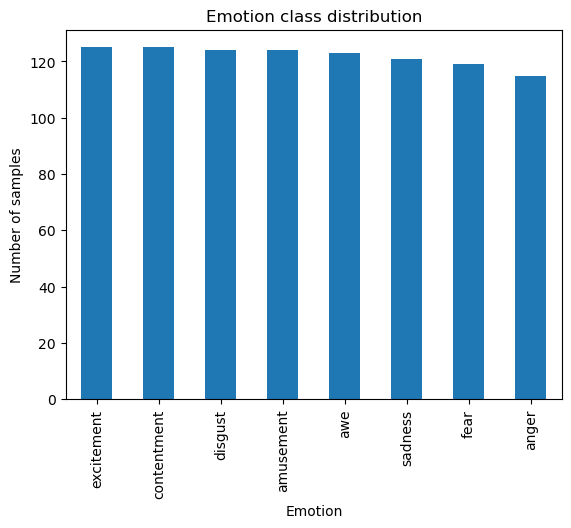

In [ ]:
# emotional label is inside a dictionary 'annotations', extracting it into its own columns  
df['emotion'] = df['annotations'].apply(lambda x: x['emotion'])
display("Emotion classes =", ", ".join(df['emotion'].unique()))
display("Number of emotion classes =", df['emotion'].nunique())
# counting samples per emotion
emotion_counts = df['emotion'].value_counts()
display(emotion_counts)
# Plotting class distribution
emotion_counts.plot(kind='bar')
plt.title("Emotion class distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of samples")
plt.show()

In [16]:
# Analyze the metadata
multilabel_metadata = ['object']
identifier_columns = ['image_id']
numeric_metadata = ['brightness', 'colorfulness']
categorical_metadata = ['facial_expression', 'human_action', 'scene']
display("Distribution of numeric metadata = ")
display(df[numeric_metadata].describe())

'Distribution of numeric metadata = '

,brightness,colorfulness
count,976.000000,976.000000
mean,0.486885,0.493545
std,0.149639,0.195302
min,0.000000,0.000000
25%,0.400000,0.400000
50%,0.500000,0.500000
75%,0.600000,0.600000
max,0.900000,1.000000


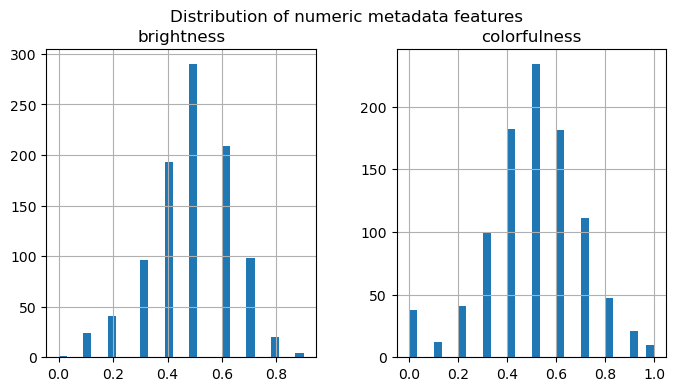

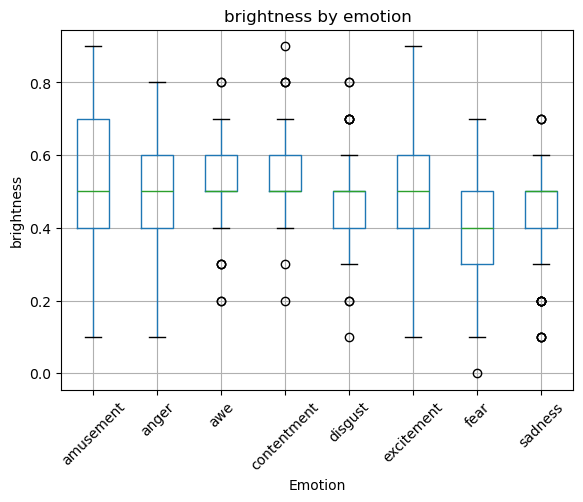

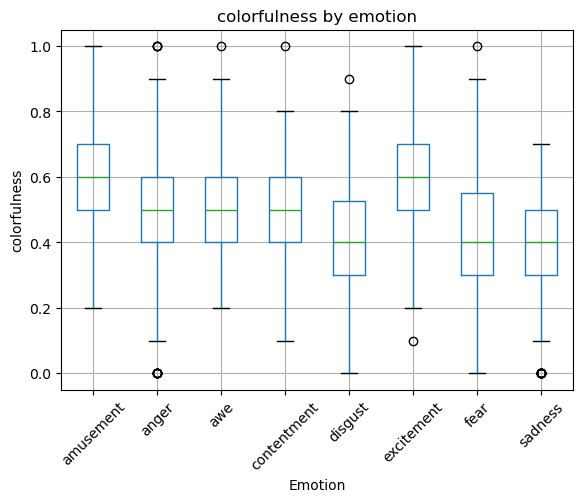

'\n--- FACIAL_EXPRESSION DISTRIBUTION ---'

facial_expression
NaN         864
happy        81
sad          13
angry        12
disgust       3
surprise      3
Name: count, dtype: int64

facial_expression,angry,disgust,happy,sad,surprise
emotion,,,,,
amusement,0,0,17,0,0
anger,11,2,0,0,0
awe,0,0,4,0,1
contentment,0,0,25,0,0
disgust,0,1,0,0,0
excitement,0,0,34,0,2
fear,1,0,1,0,0
sadness,0,0,0,13,0


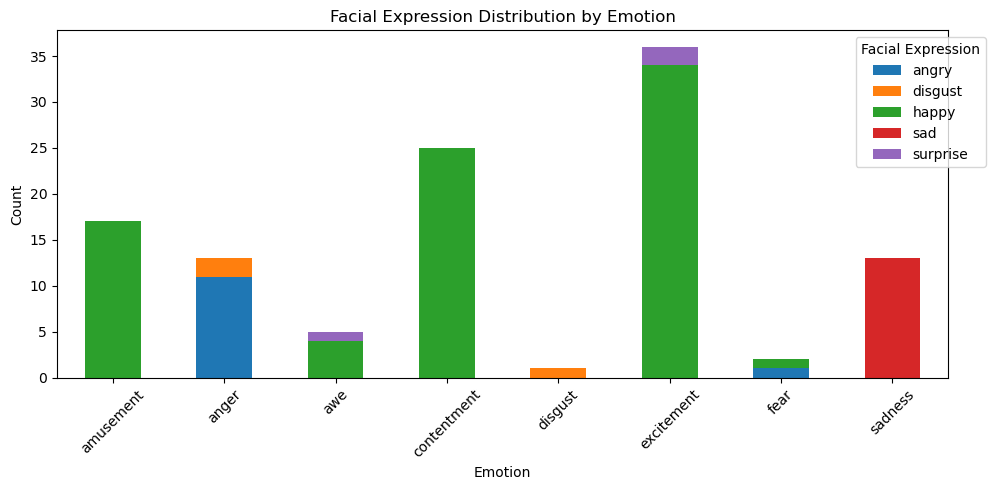

'\n--- HUMAN_ACTION DISTRIBUTION ---'

human_action
NaN                             862
laughing                         15
marching                          9
singing                           8
celebrating                       7
crying                            6
sticking tongue out               5
swinging on something             5
hugging                           4
motorcycling                      4
playing guitar                    4
stretching arm                    4
skiing                            3
surfing water                     3
playing bass guitar               3
carrying baby                     2
canoeing or kayaking              2
boxing                            2
crawling baby                     2
playing drums                     2
kicking soccer ball               2
reading book                      2
riding a bike                     2
riding or walking with horse      1
knitting                          1
dancing                           1
kitesurfing                       1
kissing        

human_action,celebrating,crying,hugging,laughing,marching,motorcycling,singing,sticking tongue out,swinging on something
emotion,,,,,,,,,
amusement,0,0,0,7,0,0,0,0,2
anger,0,0,0,0,9,0,1,0,0
awe,1,0,0,0,0,0,1,0,0
contentment,1,0,2,3,0,0,0,0,1
excitement,5,0,2,4,0,4,6,2,2
fear,0,0,0,1,0,0,0,3,0
sadness,0,6,0,0,0,0,0,0,0


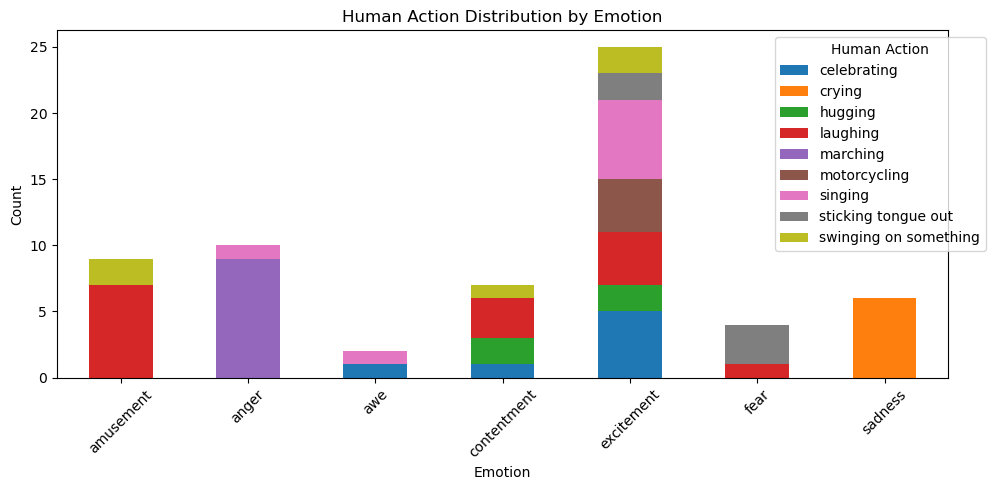

'\n--- SCENE DISTRIBUTION ---'

scene
NaN               768
cemetery           24
amusement_park     15
sky                14
street             14
                 ... 
rope_bridge         1
corral              1
bedroom             1
harbor              1
discotheque         1
Name: count, Length: 72, dtype: int64

scene,amusement_park,beach,butchers_shop,cemetery,ocean,sky,stage,street,wave
emotion,,,,,,,,,
amusement,13,0,0,0,0,2,0,0,0
anger,0,0,0,0,0,2,0,2,0
awe,0,2,0,0,3,8,0,0,0
contentment,0,2,0,0,1,0,0,0,0
disgust,0,0,7,0,0,0,0,0,0
excitement,2,1,0,0,1,1,6,11,6
fear,0,0,0,0,1,1,0,0,0
sadness,0,0,0,24,0,0,0,1,0


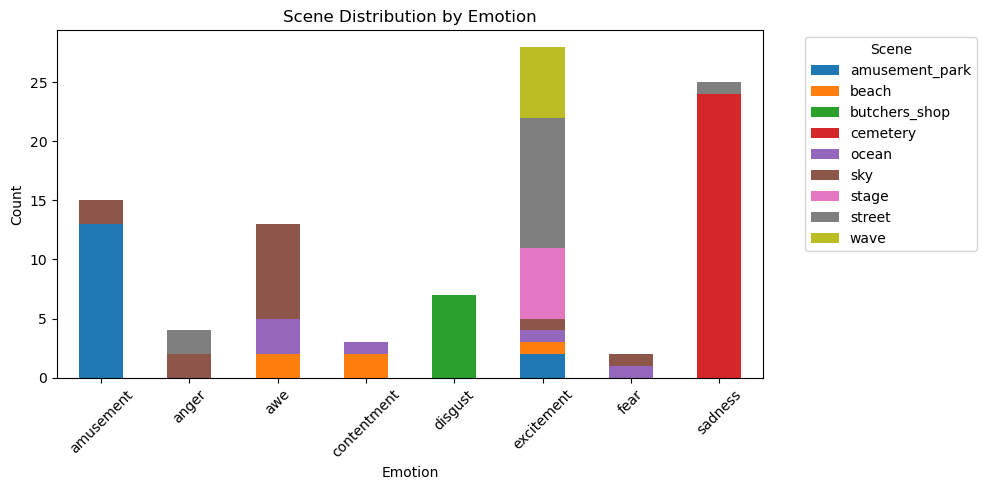

In [17]:
# 4.1 Distribution of numeric
df[numeric_metadata].hist(bins=30, figsize=(8, 4))
plt.suptitle("Distribution of numeric metadata features")
plt.show()
# checking if different emotions tend to have different brightness or colorfulness
df = df.loc[:, ~df.columns.duplicated()] # dropping the first emotions column
for feature in numeric_metadata:
    df.boxplot(column=feature, by='emotion')
    plt.title(f"{feature} by emotion")
    plt.suptitle("")  # removes automatic title
    plt.xlabel("Emotion")
    plt.ylabel(feature)
    plt.xticks(rotation=45)
    plt.show()

top_k = 10  # number of categories to keep

# 4.2 Distribution of categorical
for feature in categorical_metadata:
    display(f"\n--- {feature.upper()} DISTRIBUTION ---")
    # count occurrences (including NaNs)
    counts = df[feature].value_counts(dropna=False)
    display(counts)

    # If feature has many categories → limit to top-K
    if counts.dropna().shape[0] > top_k:
        top_categories = counts.dropna().head(top_k).index
        filtered_df = df[df[feature].isin(top_categories)]
    else:
        filtered_df = df
    by_emotion = pd.crosstab(filtered_df['emotion'], filtered_df[feature])
    display(by_emotion)

    # plotting
    by_emotion.plot(kind='bar', stacked=True, figsize=(10, 5))
    plt.title(f"{feature.replace('_', ' ').title()} Distribution by Emotion")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(
        title=feature.replace('_', ' ').title(),
        bbox_to_anchor=(1.05, 1)
    )
    plt.tight_layout()
    plt.show()

'\n--- DESCRIPTION ---'

description
False    976
Name: count, dtype: int64

'\n--- VIEWER_FEELINGS ---'

viewer_feelings
False    976
Name: count, dtype: int64

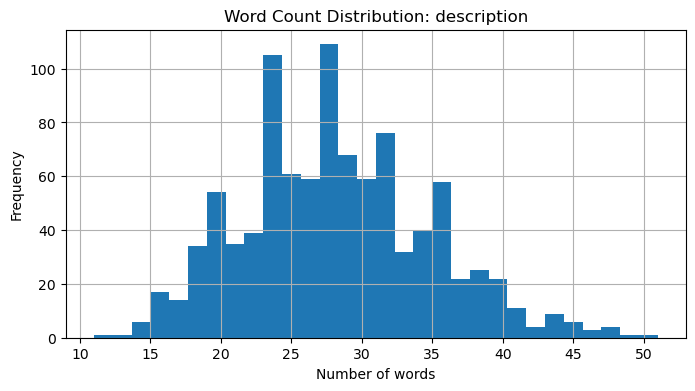

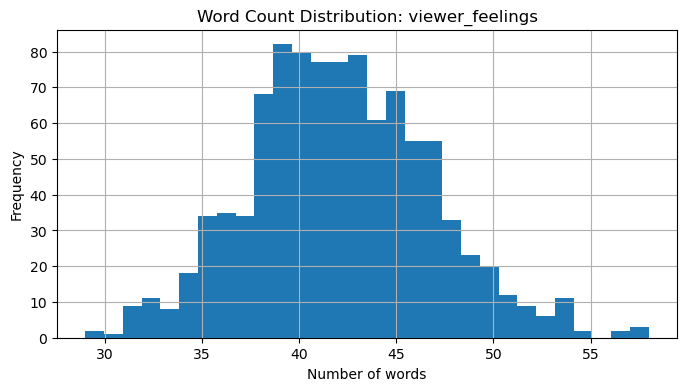

'description vocabulary size: 3076'

'viewer_feelings vocabulary size: 2659'

'\nTop words in description:'

'a: 3322'

'and: 1062'

...

'joy: 291'

'for: 280'

'as: 262'

'evoking: 252'

'scene: 239'

In [18]:
text_columns = ['description', 'viewer_feelings']

for col in text_columns: #Are there NaNs and Is one column much sparser than the other?
    display(f"\n--- {col.upper()} ---")
    display(df[col].isna().value_counts())

for col in text_columns: #Text length distributions
    df[f'{col}_length'] = df[col].fillna("").apply(lambda x: len(x.split()))

#Plot histograms
for col in text_columns:
    plt.figure(figsize=(8, 4))
    df[f'{col}_length'].hist(bins=30)
    plt.title(f"Word Count Distribution: {col}")
    plt.xlabel("Number of words")
    plt.ylabel("Frequency")
    plt.show()

#Compare statistics numerically
df[[f'{col}_length' for col in text_columns]].describe()
#Vocabulary size
import re
def get_vocab(text_series):
    words = []
    for text in text_series.dropna():
        text = text.lower()
        text = re.sub(r'[^a-z\s]', '', text)
        words.extend(text.split())
    return set(words)

for col in text_columns:
    vocab = get_vocab(df[col])
    display(f"{col} vocabulary size: {len(vocab)}")
#Most frequent words
from collections import Counter
def top_words(text_series, top_k=20):
    words = []
    for text in text_series.dropna():
        text = text.lower()
        text = re.sub(r'[^a-z\s]', '', text)
        words.extend(text.split())
    return Counter(words).most_common(top_k)
for col in text_columns:
    display(f"\nTop words in {col}:")
    for word, count in top_words(df[col]):
        display(f"{word}: {count}")

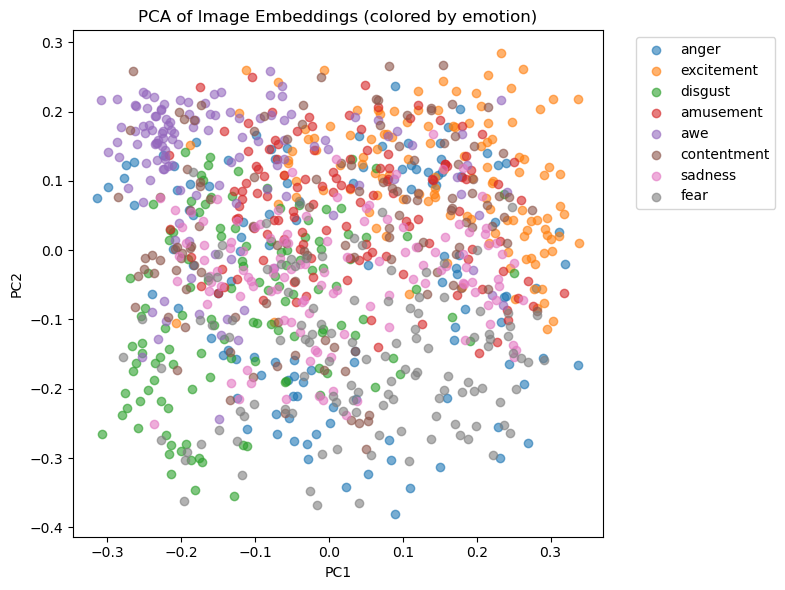

'Explained variance ratio:'

array([0.05484949, 0.04256617, 0.04184035, 0.03083678, 0.02695151,
       0.02503613, 0.02048734, 0.02038056, 0.01786477, 0.01742424,
       0.01628536, 0.01497746, 0.01457678, 0.01383543, 0.01293801,
       0.01238523, 0.01101546, 0.01087741, 0.0101879 , 0.00983522,
       0.00968208, 0.00905227, 0.00885647, 0.00845677, 0.00823253,
       0.00805106, 0.00775021, 0.00754968, 0.00719244, 0.00714415,
       0.00688713, 0.00663216, 0.00643888, 0.0063821 , 0.00609835,
       0.00599093, 0.00564868, 0.0055522 , 0.00551791, 0.00516981,
       0.00508882, 0.00506222, 0.00497447, 0.00469705, 0.00467925,
       0.00456141, 0.00448514, 0.00441819, 0.00434717, 0.00434539,
       0.00423255, 0.00415025, 0.0040767 , 0.00400153, 0.00391543,
       0.00385115, 0.00383053, 0.00372921, 0.00365835, 0.00361026,
       0.00359465, 0.00352517, 0.00349957, 0.00344868, 0.00338204,
       0.00330064, 0.00327505, 0.00323631, 0.00319159, 0.0031644 ,
       0.00310401, 0.00307556, 0.00301447, 0.00299041, 0.00293

'Total explained variance:'

np.float64(0.9007722622375279)

In [71]:
#Convert embeddings into a matrix
import numpy as np
X_image = np.vstack(df['embedding'].values)
y = df['emotion']
#Dimensionality reduction (PCA first)
from sklearn.decomposition import PCA
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_image)

#Plot and color by emotion
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for emotion in y.unique():
    idx = y == emotion
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=emotion,
        alpha=0.6
    )
plt.title("PCA of Image Embeddings (colored by emotion)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

display("Explained variance ratio:", pca.explained_variance_ratio_)
display("Total explained variance:", pca.explained_variance_ratio_.sum())

X_text = np.vstack(df['viewer_feelings_embedding'].values)

In [ ]:
# Flatten the list of objects in df['object'] and get value_counts
all_objects = df['object'].dropna().apply(lambda x: x if isinstance(x, list) else [x]).explode()

object_counts = all_objects.value_counts()
display(object_counts[:20])

object
Plant                131
Tree                  96
Building              34
House                 33
Wheel                 29
Jeans                 22
Hat                   22
Sunglasses            20
Flower                20
Fashion accessory     17
Window                15
Table                 14
Insect                13
Shorts                12
Land vehicle          12
Car                   11
Jacket                11
Sports equipment       9
Carnivore              9
Trousers               8
Name: count, dtype: int64

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15798 stored elements and shape (976, 681)>

'TFIDF ANALYSIS FOR VIEWER FEELINGS'

'TF–IDF shape: (976, 14453)'

'Vocabulary size: 14453'

'Top words for emotion: anger'

array(['witnessing', 'evoke', 'flames', 'concern', 'mix', 'viewer feel',
       'viewer', 'feel', 'sense', 'urgency'], dtype=object)

...

array(['feelings', 'feel', 'happiness', 'viewer', 'viewer feel',
       'feel sense', 'sense', 'tranquility', 'joy', 'warmth'],
      dtype=object)

'Top words for emotion: sadness'

array(['thoughts', 'time', 'empathy', 'feel', 'viewer', 'viewer feel',
       'sense', 'contemplation', 'feel sense', 'reflection'], dtype=object)

'Top words for emotion: fear'

array(['evoke', 'feel', 'viewer', 'sense unease', 'viewer feel',
       'feel mix', 'mix', 'intrigue', 'unease', 'curiosity'], dtype=object)

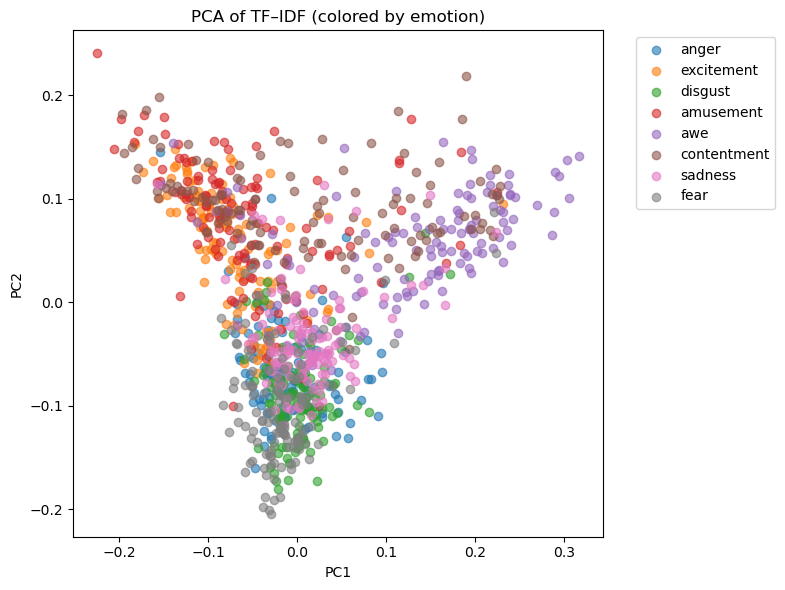

'TFIDF ANALYSIS FOR DESCRIPTION'

'TF–IDF shape: (976, 14039)'

'Vocabulary size: 14039'

'Top words for emotion: anger'

array(['stands', 'wide', 'black', 'engulfed', 'background', 'teeth',
       'open', 'smoke', 'mouth', 'flames'], dtype=object)

...

array(['blue', 'sits', 'young', 'woman', 'pink', 'background', 'flowers',
       'surrounded', 'white', 'green'], dtype=object)

'Top words for emotion: sadness'

array(['weathered', 'white', 'wooden', 'surrounded', 'partially', 'stone',
       'background', 'man', 'cemetery', 'image'], dtype=object)

'Top words for emotion: fear'

array(['image shows', 'black', 'shows', 'background', 'image features',
       'figure', 'face', 'features', 'dark', 'image'], dtype=object)

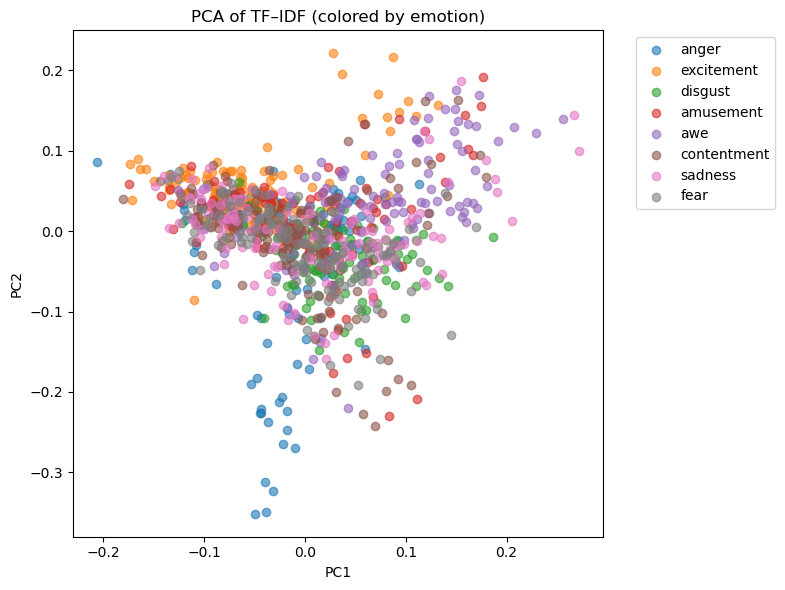

'Description vocab size:'

14039

'Viewer feelings vocab size:'

14453

'Shared vocabulary size:'

1470

'Overlap ratio (desc):'

0.1047083125578745

'Overlap ratio (feelings):'

0.1017089877534076

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def analyze_tfidf(vectorizer, X, y):
    display(f"TF–IDF shape: {X.shape}")

    #sanity-check - Vocabulary size
    display(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

    #Top TF–IDF words per emotion
    feature_names = np.array(vectorizer.get_feature_names_out())

    for emotion in y.unique():
        idx = (y == emotion).values
        mean_tfidf = X[idx].mean(axis=0)
        top_indices = np.argsort(mean_tfidf.A1)[-10:]

        display(f"Top words for emotion: {emotion}")
        display(feature_names[top_indices])

    # PCA
    X_tfidf_dense = X.toarray()
    pca = PCA(n_components=0.9)
    X_tfidf_pca = pca.fit_transform(X_tfidf_dense)

    plt.figure(figsize=(8, 6))
    for emotion in y.unique():
        idx = y == emotion
        plt.scatter(
            X_tfidf_pca[idx, 0],
            X_tfidf_pca[idx, 1],
            label=emotion,
            alpha=0.6
        )

    plt.title("PCA of TF–IDF (colored by emotion)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

# Target
y = df['emotion']

# TF-IDF on Viewer Feelings
viewer_feelings = df['viewer_feelings']

# TF–IDF vectorizer
vectorizer_params = {
    "sublinear_tf": True,
    #"max_df": 0.5,
    #"min_df": 5,
    'ngram_range': (1, 2),
    "stop_words": "english"
}
display("TFIDF ANALYSIS FOR VIEWER FEELINGS")

feelings_vectorizer = TfidfVectorizer(**vectorizer_params)
viewer_feelings_tfidf = feelings_vectorizer.fit_transform(viewer_feelings)
analyze_tfidf(feelings_vectorizer, viewer_feelings_tfidf, y)


# TF–IDF on descriptions
display("TFIDF ANALYSIS FOR DESCRIPTION")
description = df['description']

description_vectorizer = TfidfVectorizer(**vectorizer_params)
description_tfidf = description_vectorizer.fit_transform(description)
analyze_tfidf(description_vectorizer, description_tfidf, y)

#Vocabulary overlap
desc_vocab = set(description_vectorizer.vocabulary_.keys())
feel_vocab = set(feelings_vectorizer.vocabulary_.keys())

overlap = desc_vocab.intersection(feel_vocab)

display("Description vocab size:", len(desc_vocab))
display("Viewer feelings vocab size:", len(feel_vocab))
display("Shared vocabulary size:", len(overlap))
display("Overlap ratio (desc):", len(overlap) / len(desc_vocab))
display("Overlap ratio (feelings):", len(overlap) / len(feel_vocab))

In [124]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, accuracy_score,classification_report, f1_score, ConfusionMatrixDisplay
from scipy import sparse
import pandas as pd

In [125]:
df.info(show_counts=True)

# One-hot encode categorical metadata columns
categorical_cols = ['facial_expression', 'human_action', 'scene'] ## todo: we left out object because its a list...should we leave out otjer columns that dont have a lot of datA?
numeric_cols = ['brightness', 'colorfulness']


# One-hot encoding for categorical variables (handle NaNs as a separate category)
metadata_categorical = pd.get_dummies(df[categorical_cols].fillna('missing'), prefix=categorical_cols)
metadata_numeric = df[numeric_cols]

# Concatenate numeric + one-hot encoded categorical
metadata_features = pd.concat([metadata_numeric, metadata_categorical], axis=1)

# Convert metadata_features to same shape/type for sparse matrix concatenation

# Ensure the metadata is float or int before converting to sparse to avoid dtype=object issues
metadata_float = metadata_features.astype(float)
metadata_sparse = sparse.csr_matrix(metadata_float.values)

# Combine all features: metadata, viewer_feelings_tfidf, description_tfidf
X = sparse.hstack([metadata_sparse, viewer_feelings_tfidf, description_tfidf])

# Create feature_names for all columns in X
metadata_feature_names = metadata_features.columns.tolist()
viewer_feelings_feature_names = ['viewer_feelings_tfidf_' + str(word) for word in feelings_vectorizer.get_feature_names_out()]
description_feature_names = ['description_tfidf_' + str(word) for word in description_vectorizer.get_feature_names_out()]
feature_names = metadata_feature_names + viewer_feelings_feature_names + description_feature_names

y = df[['emotion']]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

display(f'Number of features: {len(feature_names)}')

<class 'pandas.core.frame.DataFrame'>
Index: 976 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   image_name                 976 non-null    object 
 1   annotations                976 non-null    object 
 2   description                976 non-null    object 
 3   embedding                  976 non-null    object 
 4   viewer_feelings            976 non-null    object 
 5   description_embedding      976 non-null    object 
 6   viewer_feelings_embedding  976 non-null    object 
 7   image_id                   976 non-null    object 
 8   emotion                    976 non-null    object 
 9   brightness                 976 non-null    float64
 10  colorfulness               976 non-null    float64
 11  facial_expression          112 non-null    object 
 12  object                     511 non-null    object 
 13  human_action               114 non-null    object 
 14 

'Number of features: 28613'

Training RandomForestClassifier...


/Users/esteerebibo/miniconda3/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 75.00%
Training GradientBoostingClassifier...


/Users/esteerebibo/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 69.90%
Training RidgeClassifier...
Accuracy: 73.98%
Training KNeighborsClassifier...
Accuracy: 55.10%
Training LogisticRegression...


/Users/esteerebibo/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1307: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/esteerebibo/miniconda3/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/esteerebibo/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/esteerebibo/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

Accuracy: 69.39%


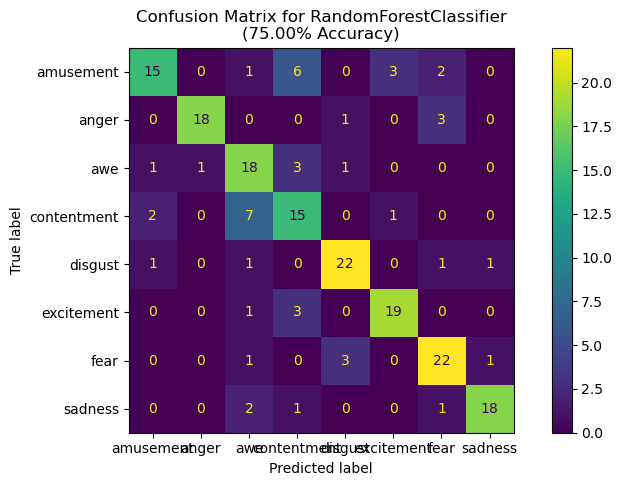

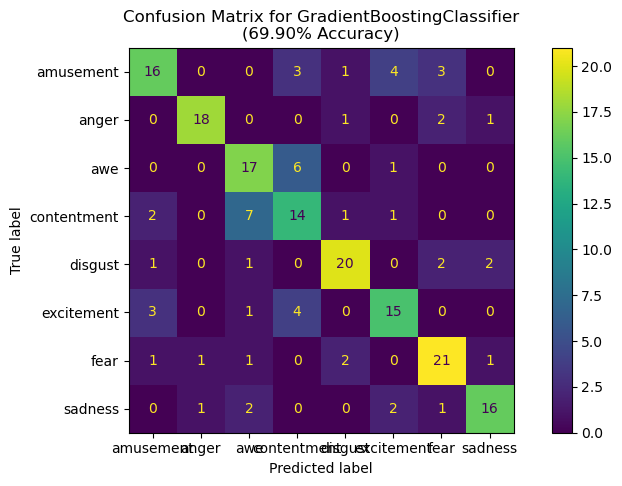

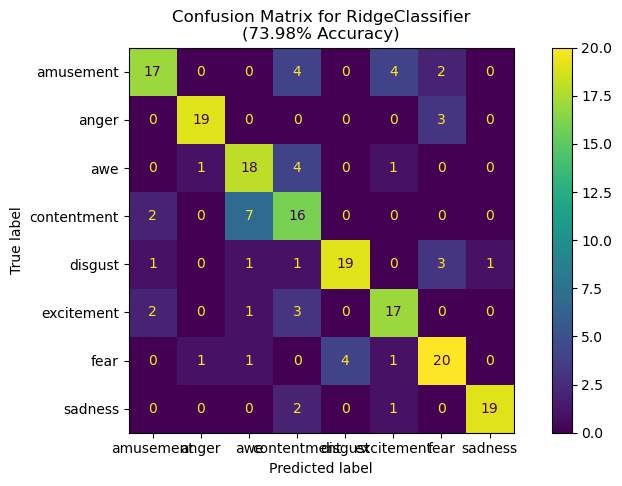

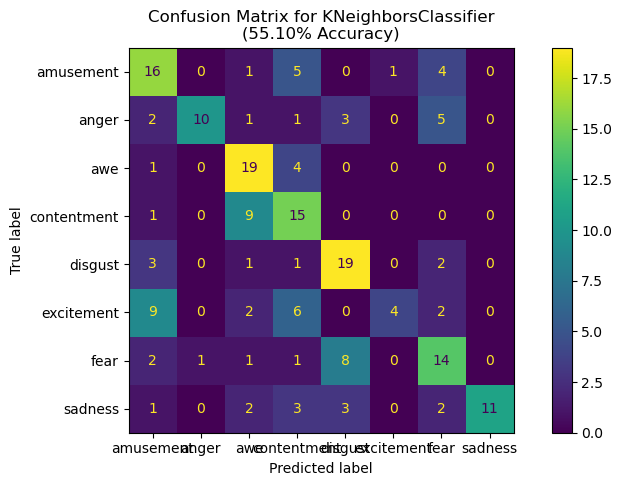

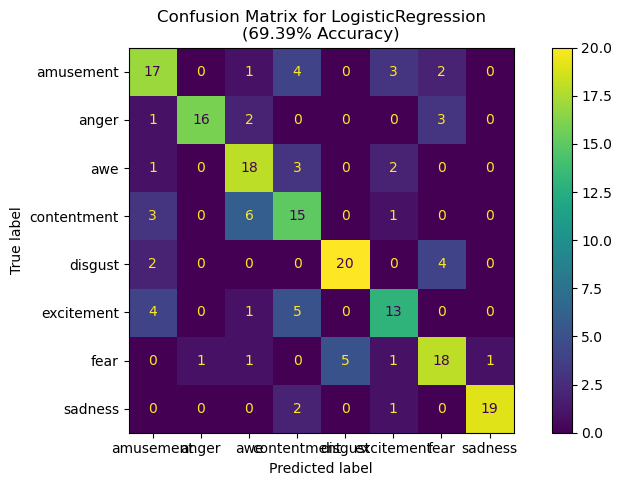

In [126]:
classifiers = [ 
    RandomForestClassifier(random_state=42),
    GradientBoostingClassifier(random_state=42),
    RidgeClassifier(tol=1e-2, solver="sparse_cg"),
    KNeighborsClassifier(n_neighbors=100),
    LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
]

USE_GRID_SEARCH = False

for clf in classifiers:
    print(f"Training {clf.__class__.__name__}...")
   
    if USE_GRID_SEARCH:
        param_grid = {
            "n_estimators": [100, 300],
            "max_depth": [None, 10, 20]
        }

        cv = GridSearchCV(clf, param_grid, cv=5)
        cv.fit(X_train, y_train)
        model = cv.best_estimator_
        print("Best parameters:", cv.best_params_)
    else:
        model = clf

    _ = model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate performance - since have balanced classes, can use accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy * 100:.2f}%')

    #print(classification_report(y_test, y_pred))
    fig, ax = plt.subplots(figsize=(10, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
    #ax.xaxis.set_ticklabels()
    #ax.yaxis.set_ticklabels(target_names)
    _ = ax.set_title(
        f"Confusion Matrix for {clf.__class__.__name__}\n({accuracy * 100:.2f}% Accuracy)"
    )
    
    # Print top features

    # importances = model.feature_importances_ if hasattr(model, "feature_importances_") else np.sum(np.abs(model.coef_), axis=0)
    # indices = np.argsort(importances)[::-1][:10]
    # print("\nTop Features:")
    # for i in indices:
    #     print(f"{feature_names[i]}: {importances[i]:.4f}")

/var/folders/30/s_w4h_316rx8c8mdx5814ctw0000gn/T/ipykernel_55532/1754297967.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")


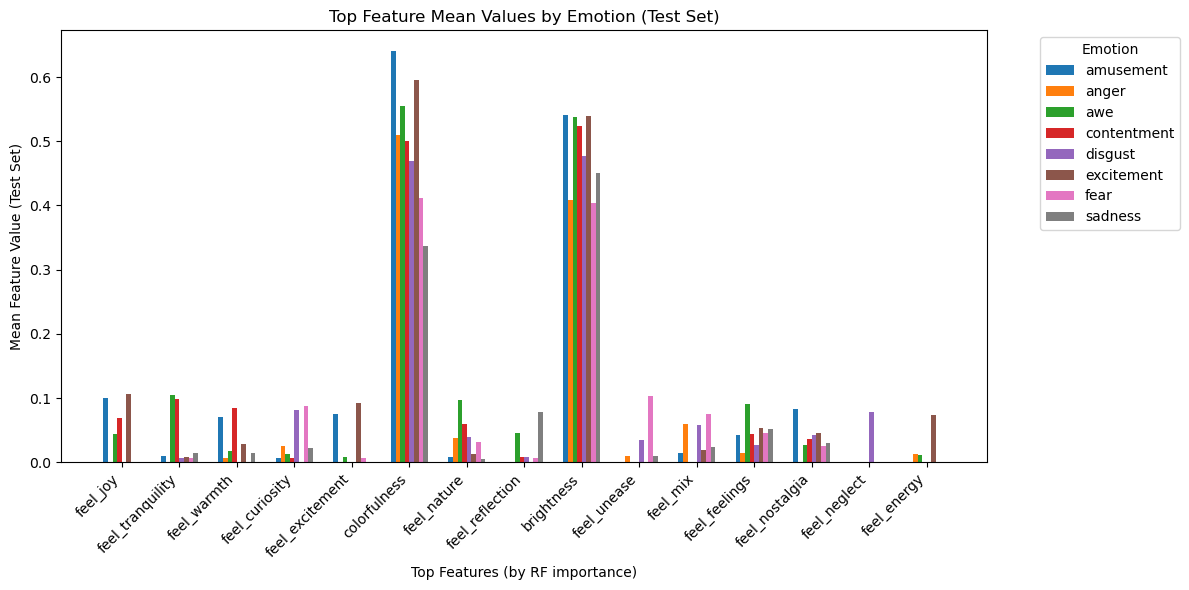

Exception ignored in: <function ResourceTracker.__del__ at 0x111dd0e00>
Traceback (most recent call last):
  File "/Users/esteerebibo/miniconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/esteerebibo/miniconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/esteerebibo/miniconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102e08e00>
Traceback (most recent call last):
  File "/Users/esteerebibo/miniconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/esteerebibo/miniconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/esteerebibo/miniconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception igno

In [ ]:
#TODO - interpret model, feature importance

In [ ]:
# PART 2: Using embeddings

## Part 2.1: Create X so it contains all embeddings, and Y is the emotion column
EMBEDDING_COLS = [
    'embedding',
    'viewer_feelings_embedding',
    'description_embedding'
]

embeddings_stacked = [np.vstack(df[col].values) for col in EMBEDDING_COLS]
X = np.hstack(embeddings_stacked)

y = df['emotion']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

Number of features: 780


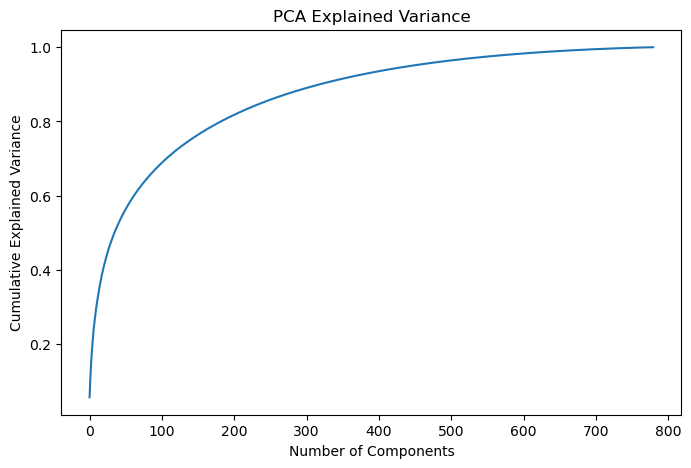

,Cumulative Variance Ratio,Explained Variance Ratio
0,0.056629,0.056629
50,0.564122,0.003494
100,0.688812,0.001863
150,0.764369,0.001256
200,0.818035,0.000929
250,0.858771,0.000714
300,0.890328,0.000557
350,0.915389,0.000449
400,0.935460,0.000359
450,0.951590,0.000290


In [57]:
# Conduct PCA 
print(f"Number of features: {len(X_train)}")
pca_test = PCA(n_components=len(X_train))
pca_test.fit(X_train)

explained_variance = pca_test.explained_variance_ratio_
cumulative_variance = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

pca_df = pd.DataFrame()
pca_df['Cumulative Variance Ratio'] = cumulative_variance
pca_df['Explained Variance Ratio'] = explained_variance
display(pca_df.iloc[::50].head(20))

In [ ]:
# Select PCA - we'll use 450 components to explain 95% of the variance
pca = PCA(n_components=450)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
# Train on several classifiers, ultimately picking the best one 
## classifiers include random forest, gradient boosting, and support vector machine
classifiers = [ 
    RandomForestClassifier(random_state=42),
    GradientBoostingClassifier(random_state=42),
    MLPClassifier(random_state=42),
    LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
]

for clf in classifiers:
    print(f"Training {clf.__class__.__name__}...")
    _ = clf.fit(X_train_pca, y_train)

    y_pred = clf.predict(X_test_pca)

    # Evaluate performance - since have balanced classes, can use accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy * 100:.2f}%')

    print(classification_report(y_test, y_pred))

Training RandomForestClassifier...
Accuracy: 75.00%
              precision    recall  f1-score   support

   amusement       0.80      0.59      0.68        27
       anger       0.90      0.86      0.88        22
         awe       0.67      0.83      0.74        24
 contentment       0.55      0.68      0.61        25
     disgust       0.79      0.88      0.84        26
  excitement       0.71      0.65      0.68        23
        fear       0.85      0.63      0.72        27
     sadness       0.83      0.91      0.87        22

    accuracy                           0.75       196
   macro avg       0.76      0.76      0.75       196
weighted avg       0.76      0.75      0.75       196

Training GradientBoostingClassifier...
Accuracy: 71.94%
              precision    recall  f1-score   support

   amusement       0.62      0.48      0.54        27
       anger       0.85      0.77      0.81        22
         awe       0.75      0.75      0.75        24
 contentment       0.55 

/Users/esteerebibo/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/esteerebibo/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
